In [19]:
pip install tensorflow pandas numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
pip install "protobuf>=3.20.2,<7.0.0"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import tensorflow as tf
print('TensorFlow version:', tf.__version__)
print('GPU Available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU Available: []


In [22]:
pip install seaborn 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.callbacks import EarlyStopping

In [24]:
# Step 2: Load Dataset
df = pd.read_csv("train.csv")
df

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
print(df.shape)
print(df.head())


(42000, 785)
   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0      

In [26]:
print(df.isnull().sum().sum())

0


In [27]:
# Step 3: Separate Features and Target
X = df.drop('label', axis = 1)
y = df['label']


In [28]:
print(X.shape)
print(y.shape)

(42000, 784)
(42000,)


In [29]:
# Step 4: Check Class Distribution
y.value_counts().sort_index()

label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64

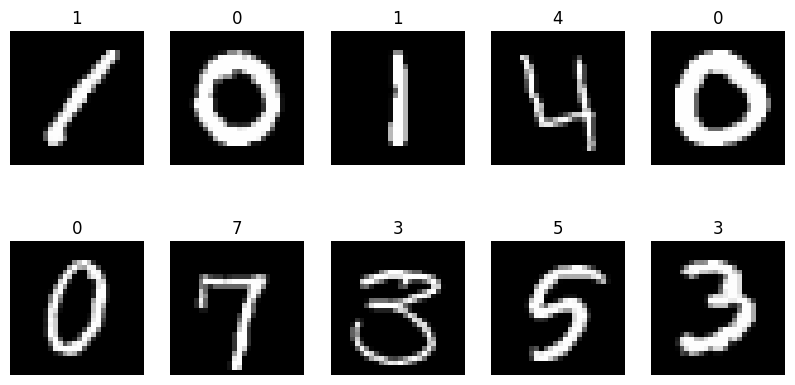

In [30]:
# Step 5: Visualize Some Images
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X.iloc[i].values.reshape(28,28), cmap='gray')
    plt.title(y.iloc[i])
    plt.axis('off')

plt.show()

In [31]:
# Step 6: Normalize Pixel Values
X = X / 255.0

In [32]:
print(X.min().min())
print(X.max().max())

0.0
1.0


In [33]:
# Step 7: One-Hot Encode Target
y = to_categorical(y)

In [34]:
print(y.shape)

(42000, 10)


In [35]:
# step 8: Split Dataset
# 60% Train, 20% Validation, 20% Test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.40, random_state = 42, stratify = y)

In [36]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [37]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(25200, 784)
(8400, 784)
(8400, 784)


In [38]:
# Step 9: Build Deep Learning Model
from tensorflow.keras.layers import BatchNormalization

model = Sequential([Dense(512, activation ='relu', input_shape=(784,)),
                    BatchNormalization(),
                    Dropout(0.3),
                    Dense(256, activation ='relu'),
                    BatchNormalization(),
                    Dropout(0.3),
                    Dense(128, activation = 'relu'),
                    Dense(10, activation = 'softmax')
                    ])

c:\Users\saisudha\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 570,506 (2.18 MB)

 Trainable params: 568,970 (2.17 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [40]:
# Step 10: Compile Model
model.compile(optimizer = 'adam',
              loss = 'categorical_crossentropy',
              metrics=['accuracy'])

In [41]:
# Step 11: Early Stopping
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights =  True
)

In [42]:
# Step 12: Train Model
history = model.fit(X_train, y_train, validation_data = (X_val, y_val),epochs = 50, batch_size=128, callbacks=[early_stop])

Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8860 - loss: 0.3697 - val_accuracy: 0.9263 - val_loss: 0.2691
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9494 - loss: 0.1580 - val_accuracy: 0.9632 - val_loss: 0.1182
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9617 - loss: 0.1185 - val_accuracy: 0.9652 - val_loss: 0.1138
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9685 - loss: 0.0957 - val_accuracy: 0.9701 - val_loss: 0.1001
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9725 - loss: 0.0836 - val_accuracy: 0.9701 - val_loss: 0.1011
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9759 - loss: 0.0720 - val_accuracy: 0.9751 - val_loss: 0.0917
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9794 - loss: 0.0602 - val_accuracy: 0.9719 - val_loss: 0.0943
Epoch 8/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9817 - loss: 0.0541 - val_accuracy: 

In [43]:
# Step 13: Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9710 - loss: 0.1030
Accuracy: 0.9709523916244507


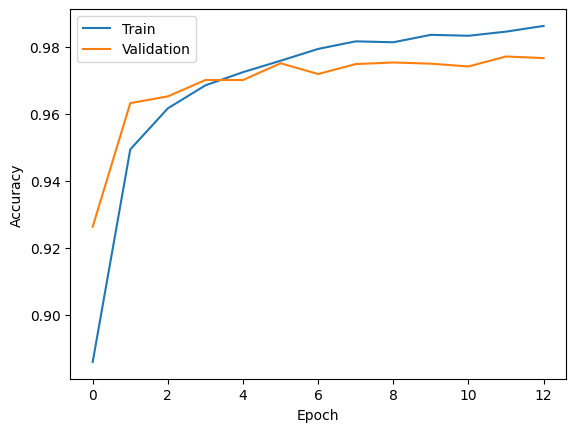

In [44]:
# Step 14: Plot Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

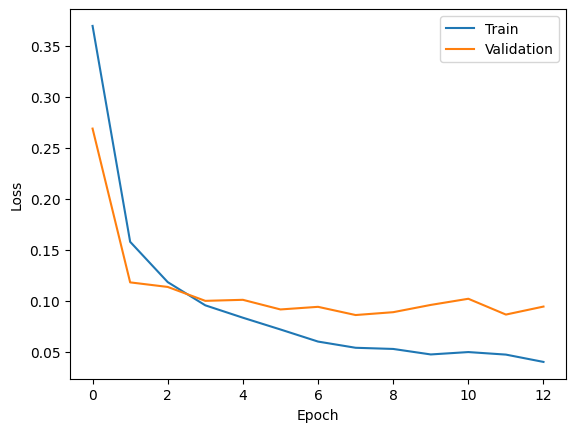

In [45]:
# Step 15: Plot Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


In [46]:
# Step 16: Make Predictions
predictions = model.predict(X_test)
pred_classes = np.argmax(predictions, axis = 1) 
actual_classes = np.argmax(y_test, axis = 1) 

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


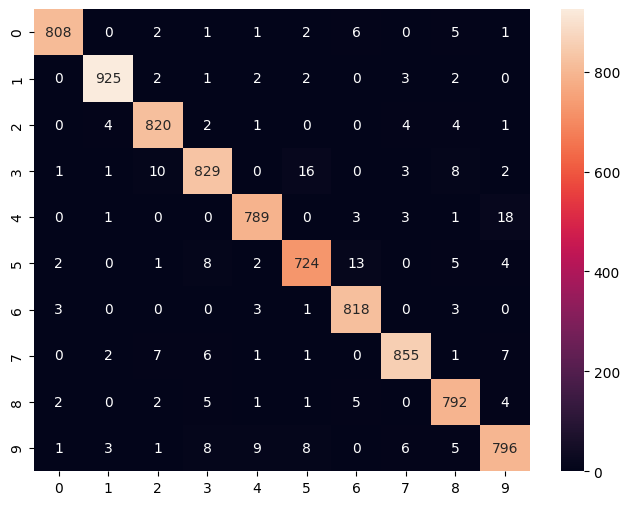

In [47]:
# Step 17: Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(actual_classes, pred_classes)
plt.figure(figsize =(8,6))
sns.heatmap(cm, annot = True, fmt ='d')
plt.show()

In [48]:
# Step 18: Classification Report
from sklearn.metrics import classification_report
print(classification_report(actual_classes, pred_classes))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       826
           1       0.99      0.99      0.99       937
           2       0.97      0.98      0.98       836
           3       0.96      0.95      0.96       870
           4       0.98      0.97      0.97       815
           5       0.96      0.95      0.96       759
           6       0.97      0.99      0.98       828
           7       0.98      0.97      0.97       880
           8       0.96      0.98      0.97       812
           9       0.96      0.95      0.95       837

    accuracy                           0.97      8400
   macro avg       0.97      0.97      0.97      8400
weighted avg       0.97      0.97      0.97      8400



In [49]:
# Save model
import joblib

joblib.dump(model, "train_model.pkl")

['train_model.pkl']

In [50]:
loaded_model = joblib.load("train_model.pkl")

In [65]:
index = 100
sample = X_test.iloc[index]
prediction = model.predict(
    sample.values.reshape(1, 784),
    verbose = 0
)
predicted_digit = np.argmax(prediction)
print("Predicted Digit :", predicted_digit)



Predicted Digit : 2


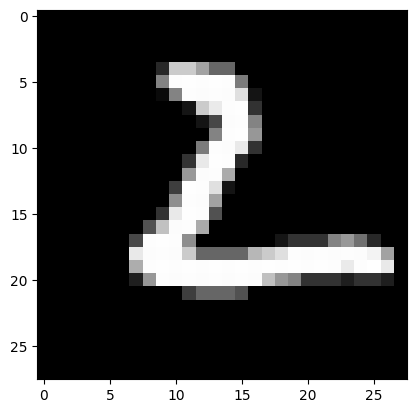

In [66]:
plt.imshow(
    sample.values.reshape(28,28),
    cmap = "gray"
)
plt.show()

In [67]:
print(np.argmax(y_test[index]))

2
